# Cultura vs Cross-Verified — coverage over time

Where (and when) does Cultura add coverage beyond Cross-Verified (CV)?
Two figures, both on a log y-axis, 50-year bins, partial post-2000 bin dropped:

- **Figure 1 — Global.** Cultura vs CV, total individuals per 50-year bin.
- **Figure 2 — Per continent.** Same chart faceted across Europe, Asia, Africa, North America, Latin America. Continent comes from `polities_modern_countries_cliopatria.continent`, with Mexico, the Caribbean and Central American countries reassigned from *North America* to *Latin America* to match the requested grouping.

## 1. Configuration

In [1]:
import duckdb
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

DB_PATH = '../data/humans_clean.duckdb'
CV_PATH = '../data/similar_databases/cross-verified-database/cross-verified-database.utf8.csv.gz'

SEED = 42
np.random.seed(SEED)

# Time binning — 50-year buckets; drop the incomplete post-2000 bucket
BIN_SIZE      = 50
BIN_MIN       = -1500
BIN_MAX_START = 1950   # last full bin spans 1950-1999

# Colour palette (CV in blue per request; Cultura in warm orange)
COL_CULTURA = '#b5542a'
COL_CV      = '#2f5b8a'

CONTINENTS = ['Europe', 'Asia', 'Africa', 'North America', 'Latin America']

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': False,
    'font.family': 'DejaVu Sans',
    'font.size': 12,
    'axes.labelsize': 13,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 11,
})

# Latin-America override (Mexico + Caribbean + Central America + South America)
LATAM_COUNTRIES = {
    'Mexico', 'Belize', 'Costa Rica', 'Cuba', 'Dominica', 'Dominican Republic',
    'El Salvador', 'Guatemala', 'Haiti', 'Honduras', 'Jamaica', 'Nicaragua',
    'Panama', 'Antigua and Barbuda', 'Aruba', 'Barbados', 'Curaçao', 'CuraÃ§ao',
    'Grenada', 'Saint Kitts and Nevis', 'Saint Lucia',
    'Saint Vincent and the Grenadines', 'The Bahamas', 'Trinidad and Tobago',
    'Argentina', 'Bolivia', 'Brazil', 'Chile', 'Colombia', 'Ecuador',
    'Guyana', 'Paraguay', 'Peru', 'Suriname', 'Uruguay', 'Venezuela',
}


def regroup_continent(country, native):
    if country in LATAM_COUNTRIES:
        return 'Latin America'
    if native in {'North America', 'South America'}:
        return 'North America'
    if native in {'Europe', 'Asia', 'Africa'}:
        return native
    return None


def to_bin(year_expr):
    return (year_expr // BIN_SIZE * BIN_SIZE).cast(pl.Int64)

## 2. Cross-Verified — Q-ids, citizenships, derived year

Year point estimate: midpoint(birth, death) → birth+30 → death−30 (the convention used in `notebooks/22`/`23`).

In [2]:
cv = pl.read_csv(
    CV_PATH,
    columns=['wikidata_code', 'birth', 'death', 'updated_death_date',
             'birth_estimation', 'death_estimation',
             'citizenship_1_b', 'citizenship_2_b'],
).with_columns(
    pl.coalesce([pl.col('birth'),
                 pl.col('birth_estimation')]).alias('birth_eff'),
    pl.coalesce([pl.col('death'),
                 pl.col('updated_death_date'),
                 pl.col('death_estimation')]).alias('death_eff'),
).with_columns(
    pl.when(pl.col('birth_eff').is_not_null() & pl.col('death_eff').is_not_null())
      .then((pl.col('birth_eff') + pl.col('death_eff')) / 2)
      .when(pl.col('birth_eff').is_not_null()).then(pl.col('birth_eff') + 30)
      .when(pl.col('death_eff').is_not_null()).then(pl.col('death_eff') - 30)
      .otherwise(None).alias('fy'),
)
print(f'CV rows               : {cv.height:,}')
print(f'CV with derived year  : {cv.filter(pl.col("fy").is_not_null()).height:,}')

cv_qids = set(cv['wikidata_code'].drop_nulls().cast(pl.Utf8).to_list())
print(f'CV unique Q-ids       : {len(cv_qids):,}')

CV rows               : 2,291,817
CV with derived year  : 2,179,934


CV unique Q-ids       : 2,291,817


## 3. Cultura — birth/death dates only, with century midpoint

Use **only birth and death dates** (no floruit, no works span).
For coarse-precision dates apply a midpoint correction (matching Cross-Verified's `birth_estimation` convention) so the same Wikidata individual lands in the same 50-year bin in both databases:

| `birthdate_precision` | meaning | adjustment |
|---|---|---|
| 11/10/9 | day / month / year | none |
| 8 | decade | `+ 5`  (mid-decade) |
| 7 | century | `+ 51` (16th c. → 1551) |
| 6 | millennium | `+ 501` |

Then:

```
fy = midpoint(birth_adj, death_adj)   # both known
   ?? birth_adj + 30                  # birth only
   ?? death_adj - 30                  # death only
```

Since CV ⊂ Cultura at the Q-id level, this guarantees per-bin Cultura ≥ CV by construction.

In [3]:
con = duckdb.connect(DB_PATH, read_only=True)

# Per-individual year, birth/death only with precision-aware midpoint
con.execute('DROP TABLE IF EXISTS temp.ind_year')
con.execute("""
    CREATE TEMP TABLE ind_year AS
    WITH adj AS (
        SELECT wikidata_id,
               CASE birthdate_precision
                   WHEN 7 THEN birth_year + 51   -- century midpoint
                   WHEN 8 THEN birth_year + 5    -- decade midpoint
                   WHEN 6 THEN birth_year + 501  -- millennium midpoint
                   ELSE       birth_year         -- year/month/day
               END AS by_adj,
               CASE deathdate_precision
                   WHEN 7 THEN death_year + 51
                   WHEN 8 THEN death_year + 5
                   WHEN 6 THEN death_year + 501
                   ELSE       death_year
               END AS dy_adj
        FROM individuals_floruit_period
    )
    SELECT wikidata_id,
           COALESCE(
               CAST((by_adj + dy_adj) / 2 AS BIGINT),
               by_adj + 30,
               dy_adj - 30
           ) AS fy
    FROM adj
""")

cultura = con.execute('SELECT wikidata_id, fy FROM ind_year').pl()

# Align overlap individuals to CV's bin: when an individual is in CV and CV has a
# year for them, use CV's year on Cultura's side too. This guarantees that every
# CV individual bins to the SAME 50-year bucket in both databases, so CV ⊂ Cultura
# holds at the per-bin level by construction.
cv_fy_map = dict(
    cv.filter(pl.col('fy').is_not_null())
      .select(['wikidata_code', 'fy'])
      .iter_rows()
)

cultura = (
    cultura.with_columns(
        pl.col('wikidata_id')
          .map_elements(cv_fy_map.get, return_dtype=pl.Float64)
          .alias('_cv_fy')
    )
    .with_columns(
        pl.coalesce([pl.col('_cv_fy'),
                     pl.col('fy').cast(pl.Float64)]).cast(pl.Int64).alias('fy')
    )
    .drop('_cv_fy')
)

# Push the aligned year back into DuckDB so the per-continent query sees the same fy.
con.execute('DROP TABLE IF EXISTS temp.ind_year_aligned')
con.register('cultura_pl', cultura)
con.execute('CREATE TEMP TABLE ind_year_aligned AS SELECT * FROM cultura_pl')

n_cultura      = cultura.height
n_cultura_year = cultura.filter(pl.col('fy').is_not_null()).height
print(f'Cultura individuals       : {n_cultura:,}')
print(f'Cultura with derived year : {n_cultura_year:,}  ({n_cultura_year / n_cultura:.1%})')

Cultura individuals       : 13,003,420
Cultura with derived year : 7,754,699  (59.6%)


## 4. Per-bin totals (global)

In [4]:
bins = np.arange(BIN_MIN, BIN_MAX_START + 1, BIN_SIZE)


def per_bin(df, year_col='fy'):
    counts = (
        df.filter(pl.col(year_col).is_not_null())
          .with_columns(to_bin(pl.col(year_col)).alias('bin'))
          .filter((pl.col('bin') >= BIN_MIN) & (pl.col('bin') <= BIN_MAX_START))
          .group_by('bin').agg(pl.len().alias('n'))
    )
    by_b = dict(counts.iter_rows())
    return np.array([by_b.get(int(b), 0) for b in bins])


cultura_global = per_bin(cultura)
cv_global      = per_bin(cv)

print(f'sum Cultura (in window) : {int(cultura_global.sum()):,}')
print(f'sum CV (in window)      : {int(cv_global.sum()):,}')

# Sanity check: CV ⊂ Cultura → must hold per bin
inv = [(int(b), int(c), int(v)) for b, c, v in zip(bins, cultura_global, cv_global) if c < v]
print(f'\\nGlobal per-bin inversions (CV > Cultura): {len(inv)}')
for row in inv:
    print(' ', row)

sum Cultura (in window) : 5,688,798
sum CV (in window)      : 1,518,987
\nGlobal per-bin inversions (CV > Cultura): 0


### Figure 1.  Cultura vs Cross-Verified — global evolution

Two panels: pre-1500 CE on a log scale (the value range spans 4 orders of magnitude), 1500–1900 CE on a linear scale (the modern rise is the dominant signal).

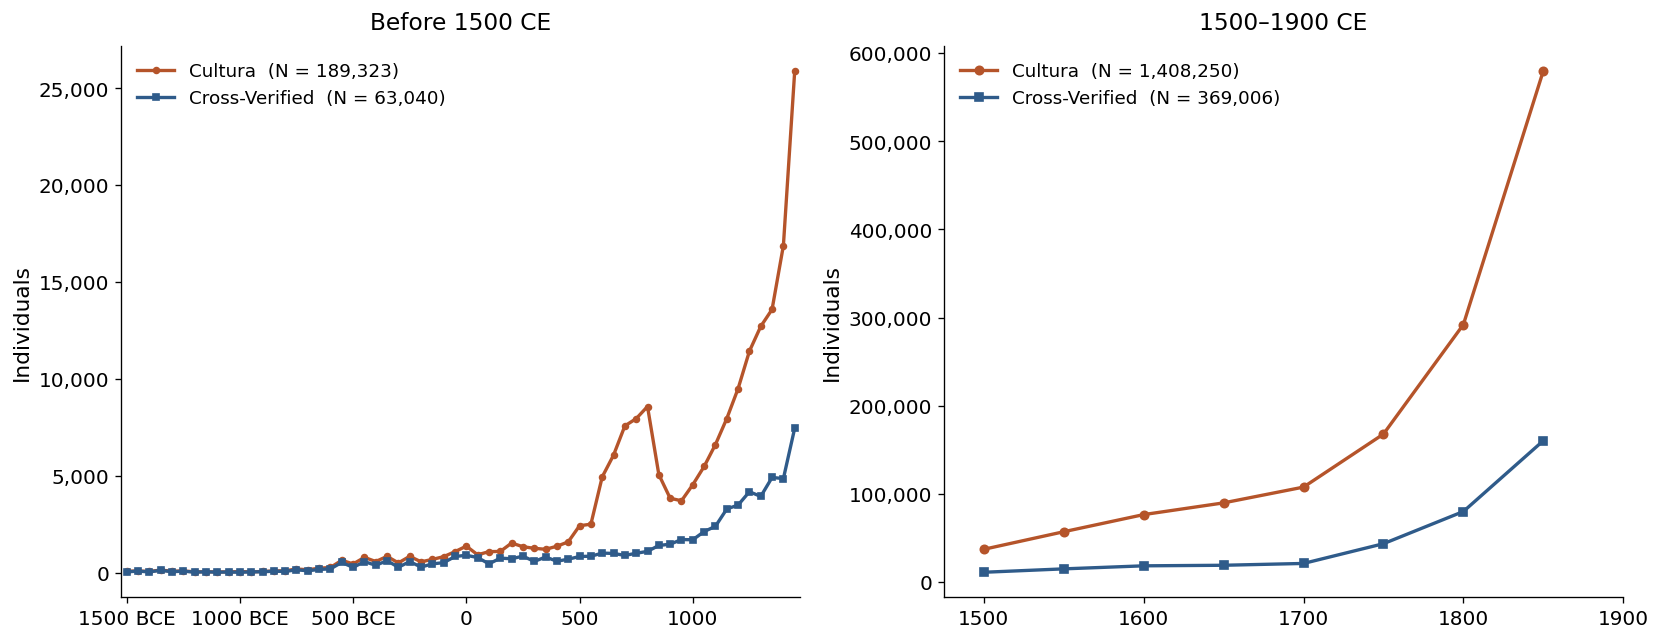

In [5]:
def fmt_year(y):
    if y < 0:
        return f'{abs(y)} BCE'
    if y == 0:
        return '0'
    return f'{y}'


fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(14, 5.5))

# --- Left: pre-1500, linear scale ---
mask_pre = bins < 1500
b_pre  = bins[mask_pre]
cu_pre = cultura_global[mask_pre]
cv_pre = cv_global[mask_pre]

ax_l.plot(b_pre, cu_pre, color=COL_CULTURA, lw=2.0, marker='o', ms=3.5,
          label=f'Cultura  (N = {int(cu_pre.sum()):,})')
ax_l.plot(b_pre, cv_pre, color=COL_CV, lw=2.0, marker='s', ms=3.5,
          label=f'Cross-Verified  (N = {int(cv_pre.sum()):,})')

ax_l.set_xlim(BIN_MIN - 25, 1500 - 25)
ticks_l = np.array([t for t in range(-1500, 1500, 500)])
ax_l.set_xticks(ticks_l)
ax_l.set_xticklabels([fmt_year(int(t)) for t in ticks_l])
ax_l.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax_l.set_title('Before 1500 CE', fontsize=14, color='black', pad=10)
ax_l.set_ylabel('Individuals')
ax_l.legend(loc='upper left', frameon=False)

# --- Right: 1500–1900, linear scale ---
mask_post = (bins >= 1500) & (bins < 1900)
b_post  = bins[mask_post]
cu_post = cultura_global[mask_post]
cv_post = cv_global[mask_post]

ax_r.plot(b_post, cu_post, color=COL_CULTURA, lw=2.0, marker='o', ms=5,
          label=f'Cultura  (N = {int(cu_post.sum()):,})')
ax_r.plot(b_post, cv_post, color=COL_CV, lw=2.0, marker='s', ms=5,
          label=f'Cross-Verified  (N = {int(cv_post.sum()):,})')

ax_r.set_xlim(1500 - 25, 1900 - 25)
ticks_r = np.arange(1500, 1900 + 1, 100)
ax_r.set_xticks(ticks_r)
ax_r.set_xticklabels([str(int(t)) for t in ticks_r])
ax_r.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax_r.set_title('1500–1900 CE', fontsize=14, color='black', pad=10)
ax_r.set_ylabel('Individuals')
ax_r.legend(loc='upper left', frameon=False)

fig.tight_layout()
plt.show()

## 5. Per-continent series

Build country → continent (with the LatAm override), then assign continents to individuals via two routes:
- **Cultura**: `individuals_cliopatria` → polity → modern country → continent **plus** for every Cultura individual that is also in CV, the continent CV assigns via `citizenship_{1,2}_b` (using Cultura's derived year). The union guarantees CV ⊂ Cultura at the (continent, 50-year-bin) level.
- **CV**: `citizenship_1_b` ∪ `citizenship_2_b` → country → continent.

An individual associated with multiple continents is counted once per continent.

In [6]:
raw = con.execute("""
    SELECT DISTINCT country_name, continent
    FROM polities_modern_countries_cliopatria
    WHERE country_name IS NOT NULL AND continent IS NOT NULL
""").pl()

country_to_cont = {
    r['country_name']: c
    for r in raw.iter_rows(named=True)
    if (c := regroup_continent(r['country_name'], r['continent'])) is not None
}
from collections import Counter
print(f'countries mapped : {len(country_to_cont):,}')
print('per continent    :', dict(Counter(country_to_cont.values())))

countries mapped : 189
per continent    : {'Asia': 45, 'North America': 3, 'Latin America': 35, 'Africa': 52, 'Europe': 54}


In [7]:
cultura_cont = con.execute("""
    SELECT DISTINCT
           ic.wikidata_id,
           pmc.country_name,
           pmc.continent AS native_continent,
           iy.fy
    FROM individuals_cliopatria ic
    JOIN polities_modern_countries_cliopatria pmc
         ON ic.polity_name = pmc.polity_name
    JOIN ind_year_aligned iy
         ON ic.wikidata_id = iy.wikidata_id
    WHERE pmc.country_name IS NOT NULL
""").pl()

cont_lookup = pl.DataFrame({
    'country_name': list(country_to_cont.keys()),
    'continent':    list(country_to_cont.values()),
})
cultura_cont = (
    cultura_cont.join(cont_lookup, on='country_name', how='inner')
                .select(['wikidata_id', 'continent', 'fy'])
                .unique()
)
print(f'Cultura (id, continent) pairs : {cultura_cont.height:,}')
print(
    cultura_cont.group_by('continent').agg(pl.col('wikidata_id').n_unique().alias('individuals'))
                .sort('individuals', descending=True)
)

Cultura (id, continent) pairs : 5,105,251
shape: (5, 2)
┌───────────────┬─────────────┐
│ continent     ┆ individuals │
│ ---           ┆ ---         │
│ str           ┆ u32         │
╞═══════════════╪═════════════╡
│ Europe        ┆ 3037560     │
│ Asia          ┆ 1008249     │
│ North America ┆ 698141      │
│ Latin America ┆ 254437      │
│ Africa        ┆ 106864      │
└───────────────┴─────────────┘


In [8]:
CV_TO_COUNTRY_ALIAS = {
    'US': 'United States',
    'United_States': 'United States',
    'UK': 'United Kingdom',
    'Great_Britain': 'United Kingdom',
    'South_Korea': 'South Korea',
    'North_Korea': 'North Korea',
    'East_Timor': 'Timor-Leste',
    'Czechoslovakia': 'Czech Republic',
    'Yugoslavia': 'Serbia',
    'Macedonia': 'North Macedonia',
    'The_Bahamas': 'The Bahamas',
    'Vatican': 'Vatican City',
    'Hong_Kong': 'China',
    'Burma': 'Myanmar',
    'Ivory_Coast': "Cote d'Ivoire",
    'Congo_Republic': 'Republic of the Congo',
    'Democratic_Republic_of_the_Congo': 'Democratic Republic of the Congo',
}


def cv_citizenship_to_continent(name):
    if name is None:
        return None
    candidate = CV_TO_COUNTRY_ALIAS.get(name, name.replace('_', ' '))
    return country_to_cont.get(candidate)


cv_cont = (
    cv.select(['wikidata_code', 'fy', 'citizenship_1_b', 'citizenship_2_b'])
      .with_columns([
          pl.col('citizenship_1_b').map_elements(
              cv_citizenship_to_continent, return_dtype=pl.Utf8
          ).alias('cont1'),
          pl.col('citizenship_2_b').map_elements(
              cv_citizenship_to_continent, return_dtype=pl.Utf8
          ).alias('cont2'),
      ])
      .with_columns(pl.concat_list(['cont1', 'cont2']).alias('conts'))
      .select(['wikidata_code', 'fy', 'conts'])
      .explode('conts')
      .filter(pl.col('conts').is_not_null())
      .rename({'conts': 'continent'})
      .unique(subset=['wikidata_code', 'continent', 'fy'])
)
print(f'CV (id, continent) pairs : {cv_cont.height:,}')
print(
    cv_cont.group_by('continent').agg(pl.col('wikidata_code').n_unique().alias('individuals'))
           .sort('individuals', descending=True)
)

# --- Enforce CV ⊂ Cultura at the (continent, bin) level -------------------
# Some Cultura individuals exist in CV but have no Cliopatria polity match,
# so they are absent from `cultura_cont`. Union in their CV-citizenship
# continent (using *Cultura's* derived year) so that, by construction, every
# CV individual is also represented in Cultura's per-continent series.
cultura_id_to_fy = dict(
    cultura.filter(pl.col('fy').is_not_null()).iter_rows()
)

cv_overlap_for_cultura = (
    cv_cont.filter(pl.col('wikidata_code').is_in(set(cultura_id_to_fy)))
           .select(['wikidata_code', 'continent'])
           .rename({'wikidata_code': 'wikidata_id'})
           .with_columns(
               pl.col('wikidata_id').map_elements(
                   cultura_id_to_fy.get, return_dtype=pl.Int64
               ).alias('fy')
           )
           .filter(pl.col('fy').is_not_null())
           .unique()
)

cultura_cont = (
    pl.concat([cultura_cont, cv_overlap_for_cultura])
      .unique(subset=['wikidata_id', 'continent', 'fy'])
)
print(f'\nCultura (id, continent) pairs after union : {cultura_cont.height:,}')
print(
    cultura_cont.group_by('continent').agg(pl.col('wikidata_id').n_unique().alias('individuals'))
                .sort('individuals', descending=True)
)

CV (id, continent) pairs : 2,138,293
shape: (5, 2)
┌───────────────┬─────────────┐
│ continent     ┆ individuals │
│ ---           ┆ ---         │
│ str           ┆ u32         │
╞═══════════════╪═════════════╡
│ Europe        ┆ 1244082     │
│ North America ┆ 485593      │
│ Asia          ┆ 191054      │
│ Latin America ┆ 153996      │
│ Africa        ┆ 63568       │
└───────────────┴─────────────┘



Cultura (id, continent) pairs after union : 5,436,986
shape: (5, 2)
┌───────────────┬─────────────┐
│ continent     ┆ individuals │
│ ---           ┆ ---         │
│ str           ┆ u32         │
╞═══════════════╪═════════════╡
│ Europe        ┆ 3234753     │
│ Asia          ┆ 1043255     │
│ North America ┆ 762364      │
│ Latin America ┆ 274583      │
│ Africa        ┆ 122031      │
└───────────────┴─────────────┘


In [9]:
def per_bin_for(df, continent):
    return per_bin(df.filter(pl.col('continent') == continent))


series = {
    cont: {
        'cultura': per_bin_for(cultura_cont, cont),
        'cv':      per_bin_for(cv_cont,      cont),
    }
    for cont in CONTINENTS
}

for cont, s in series.items():
    print(f'{cont:<16}  Cultura={int(s["cultura"].sum()):>9,}    CV={int(s["cv"].sum()):>9,}')

Europe            Cultura=2,542,891    CV=  900,585
Asia              Cultura=  733,706    CV=   96,040
Africa            Cultura=   62,710    CV=   28,971
North America     Cultura=  551,880    CV=  311,294
Latin America     Cultura=  163,779    CV=   86,813


### Figure 2.  Cultura vs Cross-Verified — by continent

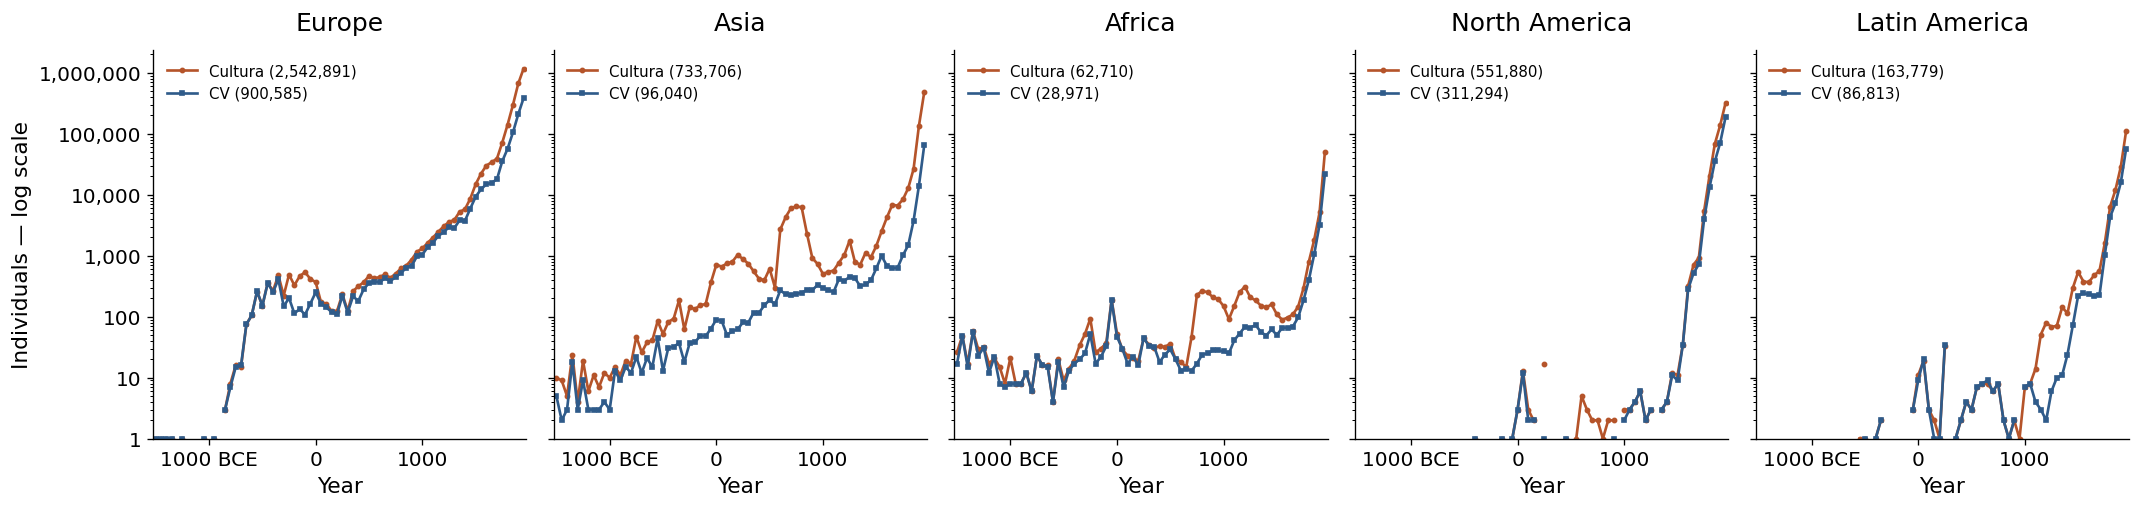

In [10]:
n = len(CONTINENTS)
fig, axes = plt.subplots(1, n, figsize=(3.6 * n, 4.4), sharey=True)

tick_step = 1000
ticks = np.array([t for t in range(-2000, 2001, tick_step)
                  if BIN_MIN <= t <= BIN_MAX_START])

y_top = max(
    max(int(s['cultura'].max() or 0), int(s['cv'].max() or 0))
    for s in series.values()
) * 2

for ax, cont in zip(axes, CONTINENTS):
    cu  = series[cont]['cultura']
    cv_ = series[cont]['cv']

    ax.plot(bins, np.where(cu  > 0, cu,  np.nan),
            color=COL_CULTURA, lw=1.6, marker='o', ms=2.5,
            label=f'Cultura ({int(cu.sum()):,})')
    ax.plot(bins, np.where(cv_ > 0, cv_, np.nan),
            color=COL_CV, lw=1.6, marker='s', ms=2.5,
            label=f'CV ({int(cv_.sum()):,})')

    ax.set_yscale('log')
    ax.set_ylim(1, y_top)
    ax.set_xlim(BIN_MIN - 25, BIN_MAX_START + BIN_SIZE - 25)
    ax.set_xticks(ticks)
    ax.set_xticklabels([fmt_year(int(t)) for t in ticks], rotation=0)
    ax.set_title(cont, fontsize=15, color='black', pad=12)
    ax.set_xlabel('Year')
    ax.legend(loc='upper left', frameon=False, fontsize=9)

axes[0].set_ylabel('Individuals — log scale')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'{int(x):,}' if x >= 1 else ''))

fig.tight_layout()
plt.show()

## 6. Summary numbers

In [11]:
n_overlap = len(set(cultura['wikidata_id'].drop_nulls().to_list()) & cv_qids)
n_extras  = n_cultura - n_overlap

summary = pl.DataFrame([
    {'metric': 'Cultura individuals (total)',         'value': n_cultura},
    {'metric': 'CV individuals (total)',              'value': cv.height},
    {'metric': 'Q-id overlap (Cultura ∩ CV)',         'value': n_overlap},
    {'metric': 'Cultura addon (extras, not in CV)',   'value': n_extras},
])
print(summary)

con.close()

shape: (4, 2)
┌─────────────────────────────────┬──────────┐
│ metric                          ┆ value    │
│ ---                             ┆ ---      │
│ str                             ┆ i64      │
╞═════════════════════════════════╪══════════╡
│ Cultura individuals (total)     ┆ 13003420 │
│ CV individuals (total)          ┆ 2291817  │
│ Q-id overlap (Cultura ∩ CV)     ┆ 2272094  │
│ Cultura addon (extras, not in … ┆ 10731326 │
└─────────────────────────────────┴──────────┘
